<a href="https://colab.research.google.com/github/mehaklaha/Machine-Learning-LAB-Repo/blob/main/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import SpectralClustering

%matplotlib inline

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("joebeachcapital/cirrhosis-patient-survival-prediction")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 11.0k/11.0k [00:00<00:00, 17.5MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1
/root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1/cirrhosis.csv


In [4]:
file_path = os.path.join(path, "cirrhosis.csv")  # adjust if needed

df = pd.read_csv(file_path)

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [5]:
df_numeric = df.select_dtypes(include=[np.number]).dropna()

df_numeric.head()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [6]:
X = df_numeric.values

print("Shape of X:", X.shape)

Shape of X: (276, 13)


In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

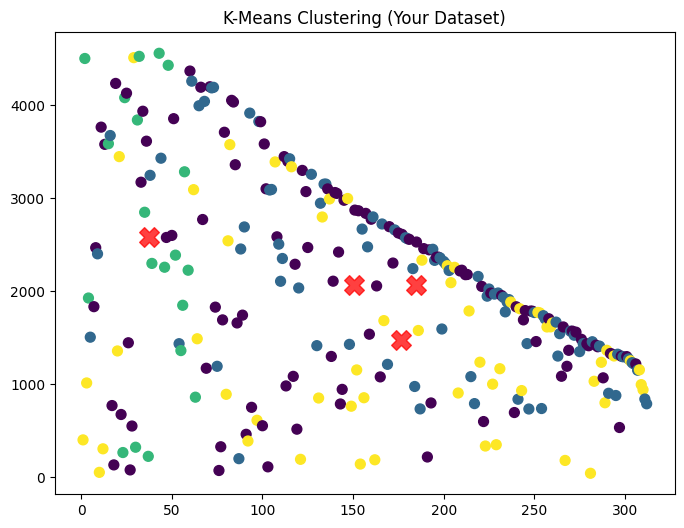

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1],
            c='red', s=200, alpha=0.75, marker='X')

plt.title("K-Means Clustering (Your Dataset)")
plt.show()

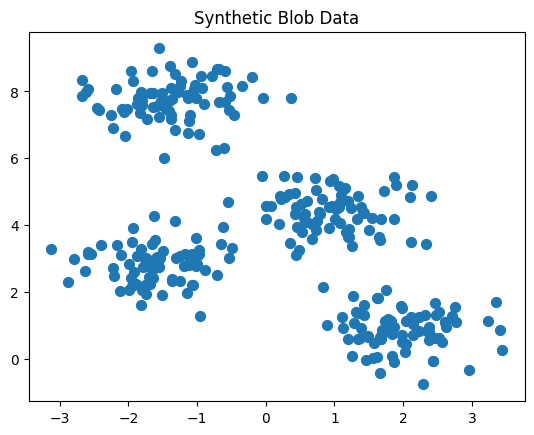

In [9]:
X_blob, y_blob = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

plt.scatter(X_blob[:, 0], X_blob[:, 1], s=50)
plt.title("Synthetic Blob Data")
plt.show()

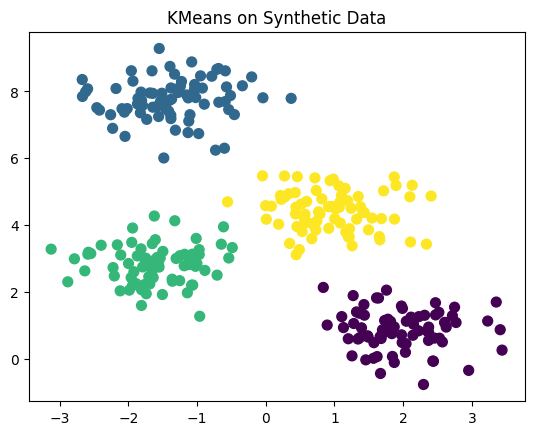

In [10]:
kmeans_blob = KMeans(n_clusters=4)

labels_blob = kmeans_blob.fit_predict(X_blob)

plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_blob, s=50, cmap='viridis')
plt.title("KMeans on Synthetic Data")
plt.show()

In [11]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        labels = pairwise_distances_argmin(X, centers)

        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        if np.all(centers == new_centers):
            break

        centers = new_centers

    return centers, labels

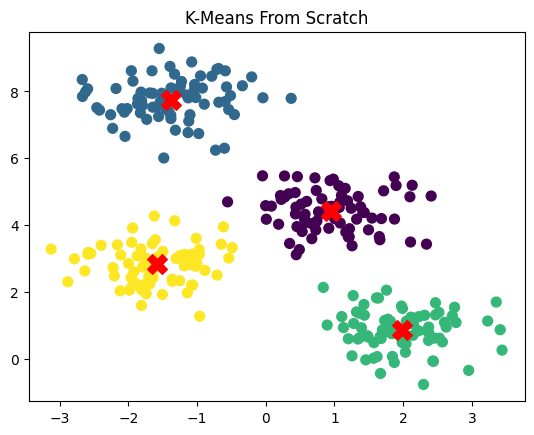

In [12]:
centers_custom, labels_custom = find_clusters(X_blob, 4)

plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_custom, s=50, cmap='viridis')
plt.scatter(centers_custom[:, 0], centers_custom[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means From Scratch")
plt.show()

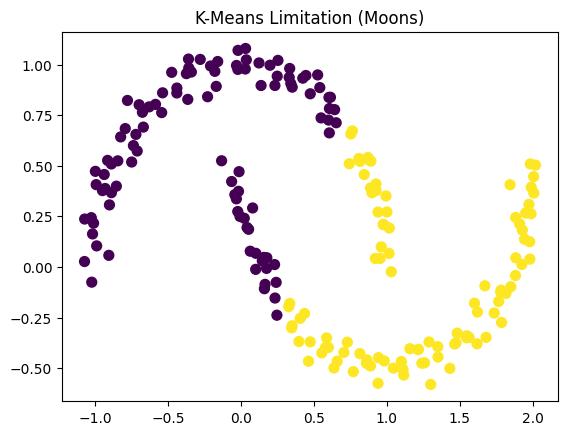

In [13]:
X_moon, y_moon = make_moons(200, noise=0.05, random_state=0)

labels_moon = KMeans(2).fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon, s=50, cmap='viridis')
plt.title("K-Means Limitation (Moons)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


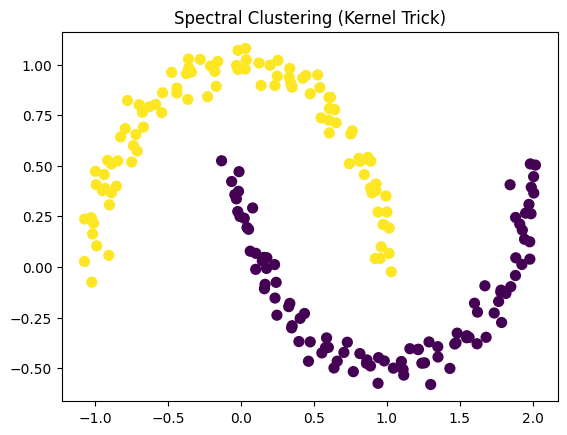

In [14]:
model = SpectralClustering(n_clusters=2,
                           affinity='nearest_neighbors',
                           assign_labels='kmeans')

labels_spec = model.fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_spec, s=50, cmap='viridis')
plt.title("Spectral Clustering (Kernel Trick)")
plt.show()